<a href="https://colab.research.google.com/github/Danny3636/Generative-AI-Tasks/blob/main/Required_Task_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**This task demonstrates a complete machine learning workflow using PyTorch, from data loading and preparation of the Fashion-MNIST dataset to defining, training, and evaluating a Multi-Layer Perceptron (MLP) model. You learned how to implement a basic neural network for image classification, including calculating accuracy and visualizing predictions.**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# Define a transformation to normalize and flatten the images
transform = transforms.Compose([
    transforms.ToTensor(), # Convert images to PyTorch tensors
    transforms.Normalize((0.5,), (0.5,)) # Normalize pixel values to be between -1 and 1
])

# Load the Fashion-MNIST training and test datasets
train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# Create DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")
print(f"Batch size: {batch_size}")


100%|██████████| 26.4M/26.4M [00:02<00:00, 13.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 252kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 4.15MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 22.1MB/s]

Number of training samples: 60000
Number of test samples: 10000
Batch size: 64


Next, let's define the Multi-Layer Perceptron (MLP) model architecture. As suggested, we can reuse a structure similar to the MNIST tutorial, with an input size of 784 (28x28 pixels) and an output size of 10 (for the 10 clothing classes).

In [2]:
class ImageMLP(nn.Module):
    def __init__(self):
        super(ImageMLP, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 256) # Input: 28x28 = 784, Hidden: 256
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(256, 128)   # Hidden: 256, Hidden: 128
        self.fc3 = nn.Linear(128, 10)    # Hidden: 128, Output: 10 classes

    def forward(self, x):
        x = x.view(-1, 28 * 28) # Flatten the 28x28 image into a 784-dimensional vector
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        return x

# Instantiate the model
model = ImageMLP()
print(model)


ImageMLP(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


Now that we have the data loaded and the model defined, let's set up the training loop. We will use `nn.CrossEntropyLoss` as the loss function and the Adam optimizer, training for 10 epochs.

In [3]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training parameters
num_epochs = 10

# Training loop
print("Starting training...")
for epoch in range(num_epochs):
    model.train() # Set the model to training mode
    running_loss = 0.0
    for i, data in enumerate(train_loader, 0):
        inputs, labels = data

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward + backward + optimize
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if i % 100 == 99:    # Print every 100 mini-batches
            print(f'Epoch [{epoch + 1}/{num_epochs}], Batch [{i + 1}/{len(train_loader)}], Loss: {running_loss / 100:.3f}')
            running_loss = 0.0

print("Finished training!")


Starting training...
Epoch [1/10], Batch [100/938], Loss: 0.839
Epoch [1/10], Batch [200/938], Loss: 0.541
Epoch [1/10], Batch [300/938], Loss: 0.500
Epoch [1/10], Batch [400/938], Loss: 0.456
Epoch [1/10], Batch [500/938], Loss: 0.436
Epoch [1/10], Batch [600/938], Loss: 0.438
Epoch [1/10], Batch [700/938], Loss: 0.438
Epoch [1/10], Batch [800/938], Loss: 0.412
Epoch [1/10], Batch [900/938], Loss: 0.404
Epoch [2/10], Batch [100/938], Loss: 0.397
Epoch [2/10], Batch [200/938], Loss: 0.359
Epoch [2/10], Batch [300/938], Loss: 0.392
Epoch [2/10], Batch [400/938], Loss: 0.374
Epoch [2/10], Batch [500/938], Loss: 0.365
Epoch [2/10], Batch [600/938], Loss: 0.353
Epoch [2/10], Batch [700/938], Loss: 0.344
Epoch [2/10], Batch [800/938], Loss: 0.354
Epoch [2/10], Batch [900/938], Loss: 0.371
Epoch [3/10], Batch [100/938], Loss: 0.320
Epoch [3/10], Batch [200/938], Loss: 0.309
Epoch [3/10], Batch [300/938], Loss: 0.345
Epoch [3/10], Batch [400/938], Loss: 0.319
Epoch [3/10], Batch [500/938], Lo

With the model trained, let's evaluate its performance on the test set and calculate the final accuracy.

In [4]:
model.eval() # Set the model to evaluation mode
correct = 0
total = 0

with torch.no_grad(): # Disable gradient calculation during evaluation
    for data in test_loader:
        images, labels = data
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f'Accuracy of the network on the 10,000 test images: {accuracy:.2f}%')


Accuracy of the network on the 10,000 test images: 87.99%


Finally, let's visualize a few correct and incorrect predictions to get a better understanding of our model's performance.

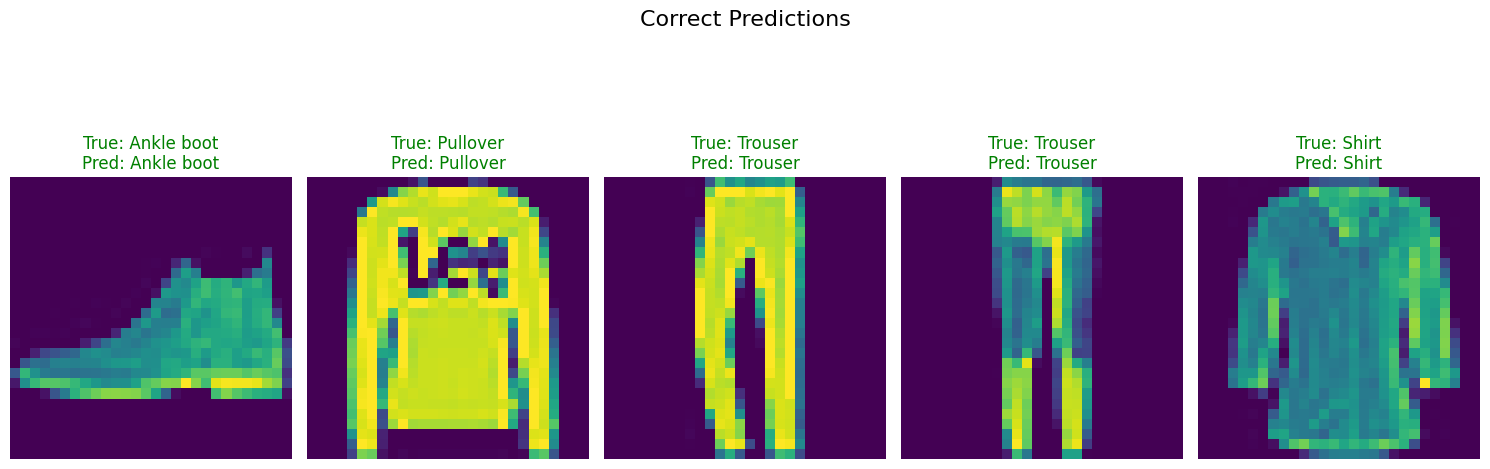

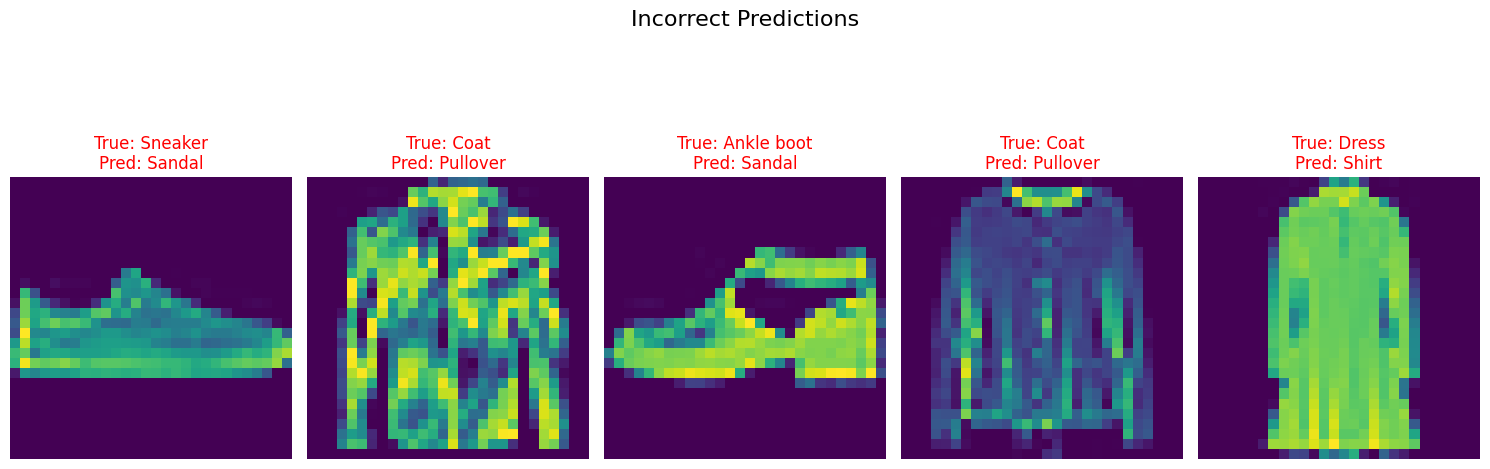

In [5]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Get a batch of test data
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Make predictions
outputs = model(images)
_, predicted = torch.max(outputs, 1)

# Find correct and incorrect predictions
correct_indices = (predicted == labels).nonzero(as_tuple=True)[0]
incorrect_indices = (predicted != labels).nonzero(as_tuple=True)[0]

# Function to unnormalize image
def imshow(img):
    img = img / 2 + 0.5  # Unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')

fig = plt.figure(figsize=(15, 10))
fig.suptitle('Correct Predictions', fontsize=16)
for i in range(min(5, len(correct_indices))):
    idx = correct_indices[i]
    ax = fig.add_subplot(2, 5, i + 1, xticks=[], yticks=[])
    imshow(images[idx])
    ax.set_title(f"True: {class_names[labels[idx]]}\nPred: {class_names[predicted[idx]]}", color="green")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

fig = plt.figure(figsize=(15, 10))
fig.suptitle('Incorrect Predictions', fontsize=16)
for i in range(min(5, len(incorrect_indices))):
    idx = incorrect_indices[i]
    ax = fig.add_subplot(2, 5, i + 1, xticks=[], yticks=[])
    imshow(images[idx])
    ax.set_title(f"True: {class_names[labels[idx]]}\nPred: {class_names[predicted[idx]]}", color="red")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
